In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [6]:
 df =  pd.read_csv("gurgaon_properties_cleaned_v2.csv")

In [7]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,the close north,sector 50,2.35,11767.0,1997.0,Super Built up area 1997(185.53 sq.m.)Built Up...,3,3,3+,...,1997.0,1950.0,1850.0,0,0,0,0,0,2,165
1,flat,ats tourmaline,sector 109,2.30,8897.0,2585.0,Super Built up area 2585(240.15 sq.m.),3,4,3+,...,2585.0,NaN,NaN,0,1,0,0,1,0,74
2,house,unitech espace,sector 50,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 ...,3,3,2,...,NaN,241.0,240.0,0,1,0,0,0,2,66
3,house,emaar mgf marbella,sector 66,NaN,NaN,NaN,Plot area 500(418.06 sq.m.),5,7,3+,...,NaN,500.0,NaN,1,1,1,1,0,2,70
4,flat,rof ananda,sector 95,0.46,6318.0,728.0,Carpet area: 728 (67.63 sq.m.),2,2,2,...,NaN,NaN,728.0,1,0,0,0,0,0,82


In [8]:
df.shape

(3803, 23)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3803 non-null   object 
 1   society              3802 non-null   object 
 2   sector               3803 non-null   object 
 3   price                3785 non-null   float64
 4   price_per_sqft       3785 non-null   float64
 5   area                 3785 non-null   float64
 6   areaWithType         3803 non-null   object 
 7   bedRoom              3803 non-null   int64  
 8   bathroom             3803 non-null   int64  
 9   balcony              3803 non-null   object 
 10  floorNum             3784 non-null   float64
 11  facing               2698 non-null   object 
 12  agePossession        3803 non-null   object 
 13  super_built_up_area  1915 non-null   float64
 14  built_up_area        1733 non-null   float64
 15  carpet_area          1944 non-null   f

In [10]:
df.duplicated().sum()

126

In [11]:
df.drop_duplicates(inplace = True)

In [12]:
df.duplicated().sum()

0

In [13]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,the close north,sector 50,2.35,11767.0,1997.0,Super Built up area 1997(185.53 sq.m.)Built Up...,3,3,3+,...,1997.0,1950.0,1850.0,0,0,0,0,0,2,165
1,flat,ats tourmaline,sector 109,2.30,8897.0,2585.0,Super Built up area 2585(240.15 sq.m.),3,4,3+,...,2585.0,NaN,NaN,0,1,0,0,1,0,74
2,house,unitech espace,sector 50,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 ...,3,3,2,...,NaN,241.0,240.0,0,1,0,0,0,2,66
3,house,emaar mgf marbella,sector 66,NaN,NaN,NaN,Plot area 500(418.06 sq.m.),5,7,3+,...,NaN,500.0,NaN,1,1,1,1,0,2,70
4,flat,rof ananda,sector 95,0.46,6318.0,728.0,Carpet area: 728 (67.63 sq.m.),2,2,2,...,NaN,NaN,728.0,1,0,0,0,0,0,82


In [14]:
df.shape

(3677, 23)

# property_type

In [15]:
df["property_type"].nunique()

2

In [16]:
df["property_type"].unique()

array(['flat', 'house'], dtype=object)

In [17]:
df["property_type"].value_counts(normalize =True)*100

property_type
flat     76.638564
house    23.361436
Name: proportion, dtype: float64

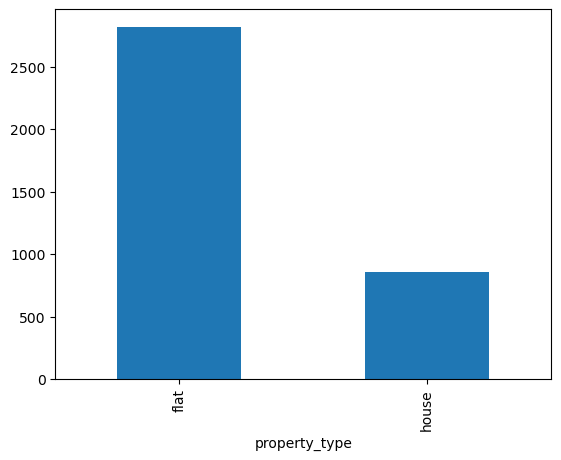

In [18]:
df["property_type"].value_counts().plot(kind = "bar");

# Observations
- Flats are in majority(75 percent) and there are less number of houses(~25 percent)
- No missing values

# society

In [21]:
df["society"].nunique()

676

In [28]:
df["society"].value_counts().shape

(676,)

In [48]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.023511
ss the leaf                             0.046395
shapoorji pallonji joyville gurugram    0.059561
dlf new town heights                    0.072727
signature global park                   0.083699
                                          ...   
umang monsoon breeze                    0.490282
puri emerald bay                        0.494357
dlf the primus                          0.498433
mvn athens                              0.502194
central park flower valley              0.505956
Name: proportion, Length: 75, dtype: float64

In [53]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': 1,
 'High (50-100)': 2,
 'Average (10-49)': 92,
 'Low (2-9)': 273,
 'Very Low (1)': 308}

<Axes: xlabel='society'>

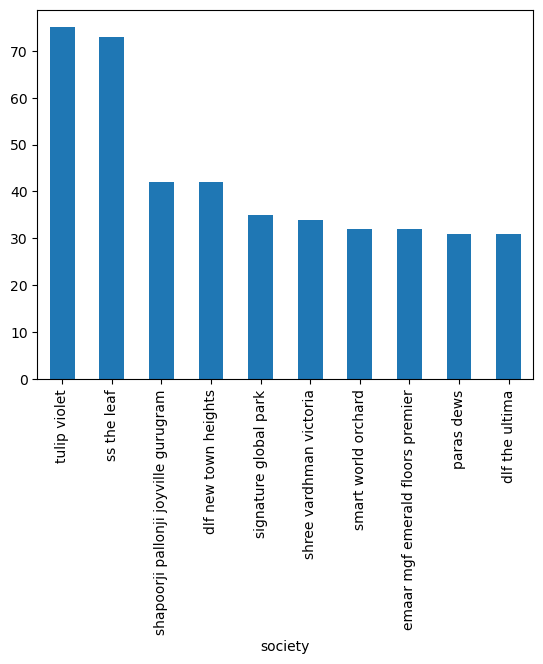

In [54]:
# top 10 socities
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [58]:
df["society"].isnull().sum()

1

In [60]:
df[df["society"].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2603,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,0,0


# Observations
- Around 13% properties comes under independent tag.
- There are 675 societies.
- The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
  - Very High (>100): Only 1 society has more than 100 listings.
  - High (50-100): 2 societies have between 50 to 100 listings.
  - Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
  - Low (2-9): 273 societies have between 2 to 9 listings.
  - Very Low (1): A significant number, 308 societies, have only 1 listing.
- 1 missing value

In [61]:
df["sector"]

0        sector 50
1       sector 109
2        sector 50
3        sector 66
4        sector 95
           ...    
3798     sector 90
3799     sector 11
3800     sector 11
3801     sector 49
3802     sector 9a
Name: sector, Length: 3677, dtype: object

# Sector

In [63]:
df["sector"].nunique()

115

In [67]:
# unique sectors
df['sector'].value_counts().shape

(115,)

In [68]:
df["sector"].value_counts()

sector
sohna road    154
sector 85     108
sector 102    107
sector 92      99
sector 69      93
             ... 
sector 88b      3
sector 73       3
sector 17a      3
sector 17b      3
sector 37       1
Name: count, Length: 115, dtype: int64

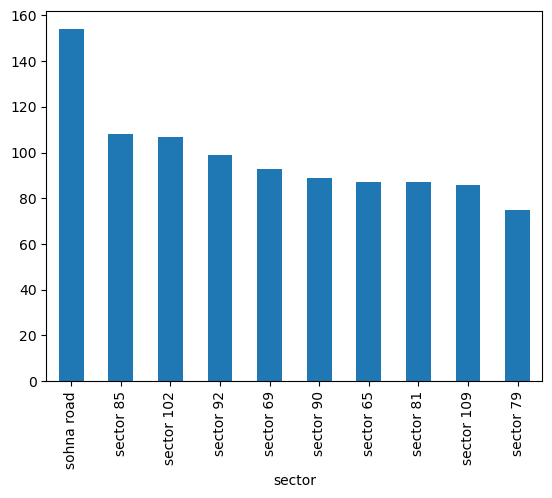

In [71]:
df["sector"].value_counts().head(10).plot(kind ="bar");

In [72]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': 3,
 'High (50-100)': 25,
 'Average (10-49)': 63,
 'Low (2-9)': 23,
 'Very Low (1)': 1}

# Observations
- There are three categories whose frequency is more than 100 and so on.........
- There are a total of 104 unique sectors in the dataset.
- Frequency distribution of sectors:
  - Very High (>100): 3 sectors have more than 100 listings.
  - High (50-100): 25 sectors have between 50 to 100 listings.
  - Average (10-49): A majority, 60 sectors, fall in this range with 10 to 49 listings each.
  - Low (2-9): 16 sectors have between 2 to 9 listings.
- Very Low (1): Interestingly, there are no sectors with only 1 listing.

# price

In [73]:
df["price"].isnull().sum()

17

In [75]:
df["price"].describe()

count    3660.000000
mean        2.533664
std         2.980623
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

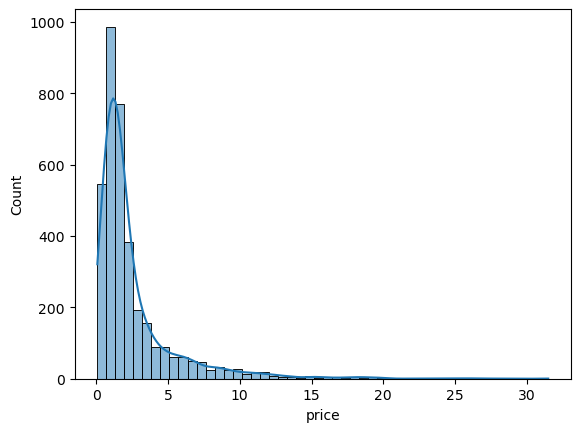

In [76]:
sns.histplot(df['price'], kde=True, bins=50)

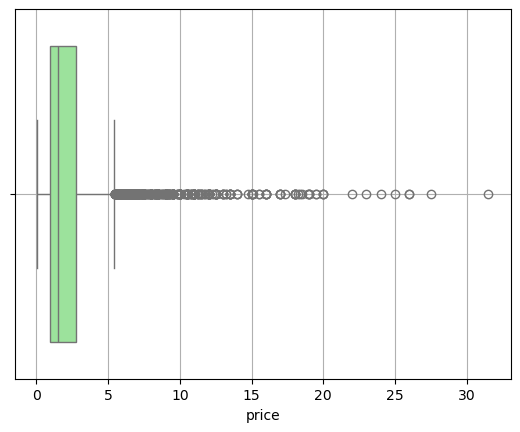

In [79]:
sns.boxplot(x=df['price'], color='lightgreen')
plt.grid()

# Descriptive Statistics:

 - Count: There are 3,660 non-missing price entries.
 - Mean Price: The average price is approximately 2.53 crores.
 - Median Price: The median (or 50th percentile) price is 1.52 crores.
 - Standard Deviation: The prices have a standard deviation of 2.98, indicating variability in the prices.
 - Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
 - IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.


- Visualizations:

 - Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
 - Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.
 - Missing Values: There are 17 missing values in the price column.

In [80]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.2791704733134615 14.933372629214254


- Skewness: The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

- Kurtosis: The kurtosis value is approximately 14.93. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.